     d     P(≥1)     P(≥2)     P(≥3)     P(≥4)
----------------------------------------------------
  0.10    0.1000    0.0000    0.0000    0.0000  
  0.20    0.1999    0.0000    0.0000    0.0000  
  0.30    0.2998    0.0000    0.0000    0.0000  
  0.40    0.4000    0.0000    0.0000    0.0000  
  0.50    0.5002    0.0000    0.0000    0.0000  
  0.60    0.6001    0.0000    0.0000    0.0000  
  0.70    0.6998    0.0000    0.0000    0.0000  
  0.80    0.7998    0.0000    0.0000    0.0000  
  0.90    0.8997    0.0000    0.0000    0.0000  
  1.00    1.0000    0.0000    0.0000    0.0000  
  1.50    1.0000    0.4998    0.0000    0.0000  
  2.00    1.0000    1.0000    0.0000    0.0000  
  3.00    1.0000    1.0000    1.0000    0.0000  


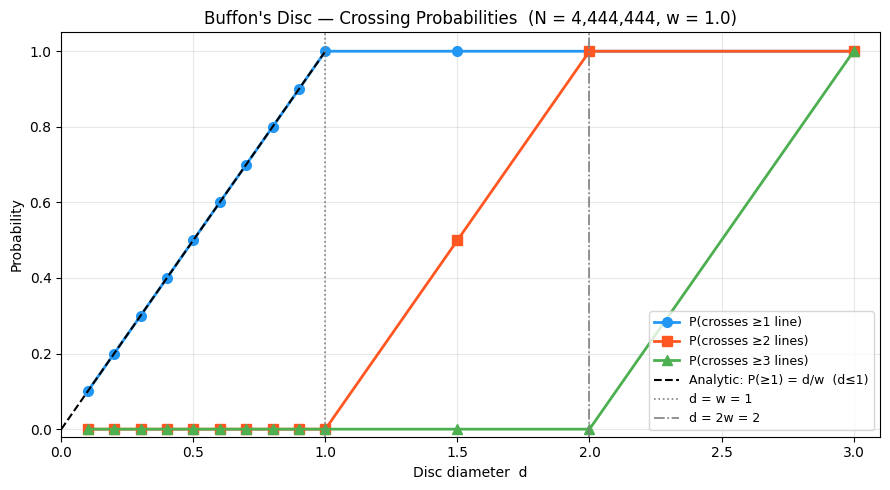

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 4_444_444
w = 1.0
rng = np.random.default_rng(42)

diameters = [1/10, 2/10, 3/10, 4/10, 5/10,
             6/10, 7/10, 8/10, 9/10, 10/10,
             15/10, 20/10, 30/10]

yc = rng.uniform(0, 1, N)

def buffon_disc(d, yc, w=1.0):
    """
    #Crossed Lines = #Integer Between [yc - r, yc + r] = floor(yc + r) - ceil(yc - r) + 1  (max with 0)
    """
    r = d / 2.0
    lo = np.ceil(yc - r).astype(int)
    hi = np.floor(yc + r).astype(int)
    n_cross = np.maximum(hi - lo + 1, 0)

    max_k = int(n_cross.max())
    probs = {}
    for k in range(1, max_k + 1):
        probs[k] = (n_cross >= k).mean()
    return probs

results = {}
print(f"{'d':>6}  {'P(≥1)':>8}  {'P(≥2)':>8}  {'P(≥3)':>8}  {'P(≥4)':>8}")
print("-" * 52)

for d in diameters:
    probs = buffon_disc(d, yc, w)
    results[d] = probs
    row = f"{d:6.2f}  "
    for k in range(1, 5):
        row += f"{probs.get(k, 0.0):8.4f}  "
    print(row)

max_k_global = max(max(p.keys(), default=0) for p in results.values())
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
markers = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(9, 5))

for k in range(1, max_k_global + 1):
    xs = [d for d in diameters]
    ys = [results[d].get(k, 0.0) for d in diameters]
    ax.plot(xs, ys,
            color=colors[(k-1) % len(colors)],
            marker=markers[(k-1) % len(markers)],
            linewidth=2, markersize=7,
            label=f'P(crosses ≥{k} line{"s" if k>1 else ""})')

d_fine = np.linspace(0, 1, 300)
ax.plot(d_fine, d_fine / w, 'k--', lw=1.5,
        label='Analytic: P(≥1) = d/w  (d≤1)')

ax.axvline(1.0, color='gray', ls=':',  lw=1.2, label='d = w = 1')
ax.axvline(2.0, color='gray', ls='-.', lw=1.2, label='d = 2w = 2')

ax.set_xlabel('Disc diameter  d')
ax.set_ylabel('Probability')
ax.set_title(f"Buffon's Disc — Crossing Probabilities  (N = {N:,}, w = {w})")
ax.set_xlim(0, 3.1);  ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()

Optimal Area  : 0.587349
Optimal Center  : cx = 0.00055,  cy = -0.01917
Optimal Angle  : α  = 178.10°


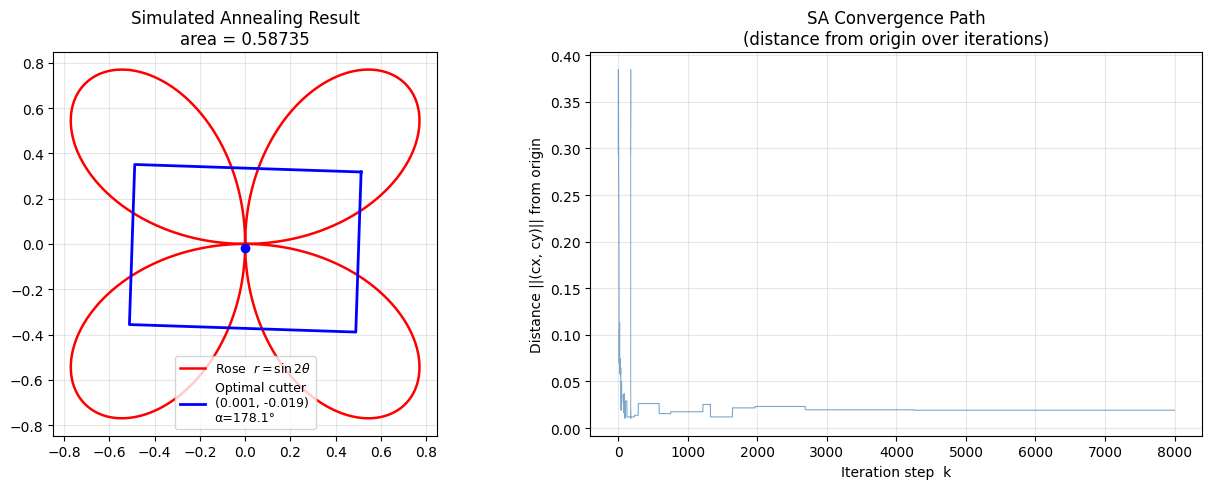

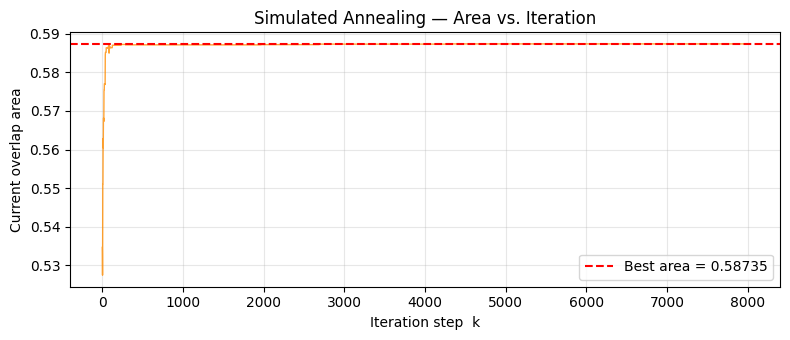

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def in_rose(x, y):
    r2 = x**2 + y**2
    return r2**3 <= 4 * x**2 * y**2

def in_rectangle(x, y, cx, cy, alpha, W=1.0, H=1.0/np.sqrt(2)):
    dx, dy = x - cx, y - cy
    cos_a, sin_a = np.cos(alpha), np.sin(alpha)
    xr =  cos_a * dx + sin_a * dy
    yr = -sin_a * dx + cos_a * dy
    return (np.abs(xr) <= W / 2) & (np.abs(yr) <= H / 2)

N_MC   = 2_000_000
BOX    = 1.1
px     = rng.uniform(-BOX, BOX, N_MC)
py     = rng.uniform(-BOX, BOX, N_MC)
in_r   = in_rose(px, py)
AREA_BOX = (2 * BOX) ** 2

def rose_cutter_area(cx, cy, alpha):
    in_rect = in_rectangle(px, py, cx, cy, alpha)
    return AREA_BOX * np.sum(in_r & in_rect) / N_MC

# Simulated Annealing
x0 = rng.uniform([-0.5, -0.5, 0], [0.5, 0.5, np.pi])
cx, cy, alpha = x0

current_area = rose_cutter_area(cx, cy, alpha)
best_area    = current_area
best_params  = (cx, cy, alpha)

T0          = 0.05
N_STEPS     = 8000
step_size   = 0.08

history_area = [current_area]
history_dist = [np.sqrt(cx**2 + cy**2)]

for k in range(1, N_STEPS + 1):
    # Fast Annealing
    T = T0 / k

    dcx    = rng.uniform(-step_size, step_size)
    dcy    = rng.uniform(-step_size, step_size)
    dalpha = rng.uniform(-step_size, step_size)

    cx_new    = cx    + dcx
    cy_new    = cy    + dcy
    alpha_new = alpha + dalpha

    cx_new    = np.clip(cx_new,    -1.0, 1.0)
    cy_new    = np.clip(cy_new,    -1.0, 1.0)
    alpha_new = alpha_new % np.pi

    new_area = rose_cutter_area(cx_new, cy_new, alpha_new)

    delta_E = -(new_area - current_area)
    P_accept = min(1.0, np.exp(-delta_E / T))

    if rng.random() < P_accept:
        cx, cy, alpha = cx_new, cy_new, alpha_new
        current_area  = new_area

    if current_area > best_area:
        best_area   = current_area
        best_params = (cx, cy, alpha)

    history_area.append(current_area)
    history_dist.append(np.sqrt(cx**2 + cy**2))

cx_opt, cy_opt, alpha_opt = best_params
print(f"Optimal Area  : {best_area:.6f}")
print(f"Optimal Center  : cx = {cx_opt:.5f},  cy = {cy_opt:.5f}")
print(f"Optimal Angle  : α  = {np.degrees(alpha_opt) % 180:.2f}°")

theta   = np.linspace(0, 2*np.pi, 800)
xr_rose = np.abs(np.sin(2*theta)) * np.cos(theta)
yr_rose = np.abs(np.sin(2*theta)) * np.sin(theta)

H_half  = 0.5 / np.sqrt(2)
corners = np.array([[-0.5,-H_half],[0.5,-H_half],
                    [ 0.5, H_half],[-0.5, H_half],[-0.5,-H_half]])
cos_o, sin_o = np.cos(alpha_opt), np.sin(alpha_opt)
rot = np.array([[cos_o, -sin_o], [sin_o, cos_o]])
cw  = corners @ rot.T + np.array([cx_opt, cy_opt])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(xr_rose, yr_rose, 'r', lw=1.8, label='Rose  $r=\\sin 2\\theta$')
ax1.plot(cw[:,0], cw[:,1], 'b-', lw=2,
         label=f'Optimal cutter\n({cx_opt:.3f}, {cy_opt:.3f})\nα={np.degrees(alpha_opt)%180:.1f}°')
ax1.scatter(cx_opt, cy_opt, c='blue', zorder=5)
ax1.set_aspect('equal')
ax1.set_title(f'Simulated Annealing Result\narea = {best_area:.5f}')
ax1.legend(fontsize=9);  ax1.grid(True, alpha=0.3)

steps = np.arange(len(history_dist))
ax2.plot(np.degrees(np.array([cx for cx in
         [x0[2]] + [best_params[2]]*N_STEPS]) % np.pi),
         history_dist,
         color='steelblue', alpha=0.6, lw=0.8)
ax2.plot(steps, history_dist, color='steelblue', lw=0.8, alpha=0.7)
ax2.set_xlabel('Iteration step  k')
ax2.set_ylabel('Distance ||(cx, cy)|| from origin')
ax2.set_title('SA Convergence Path\n(distance from origin over iterations)')
ax2.grid(True, alpha=0.3)

plt.tight_layout();  plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(history_area, color='darkorange', lw=1, alpha=0.8)
ax.axhline(best_area, color='red', ls='--', lw=1.5,
           label=f'Best area = {best_area:.5f}')
ax.set_xlabel('Iteration step  k')
ax.set_ylabel('Current overlap area')
ax.set_title('Simulated Annealing — Area vs. Iteration')
ax.legend();  ax.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()

k = w/v0 = 0.500000
#Integrate Steps      : 2005
End Point      : x = 0.0000,  y = 0.0003
Distance to Original    : 0.00029
Heighest y_max  = 19.2431  at  x = 33.3144


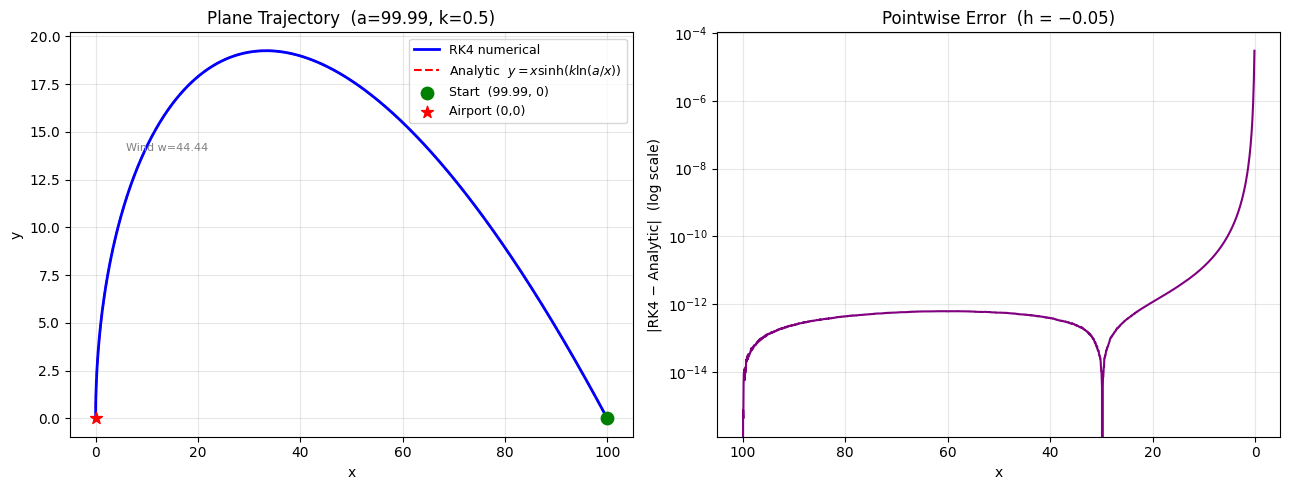

    x  y (RK4)  y (analytic)  |error|  dist to (0,0)
99.99   0.0000        0.0000  0.00000        99.9900
94.74   2.5552        2.5552  0.00000        94.7745
89.49   4.9667        4.9667  0.00000        89.6277
84.19   7.2490        7.2490  0.00000        84.5015
78.94   9.3517        9.3517  0.00000        79.4920
73.64  11.3065       11.3065  0.00000        74.5029
68.39  13.0670       13.0670  0.00000        69.6271
63.09  14.6554       14.6554  0.00000        64.7698
57.84  16.0289       16.0289  0.00000        60.0199
52.54  17.1978       17.1978  0.00000        55.2831
47.29  18.1212       18.1212  0.00000        50.6431
41.99  18.7929       18.7929  0.00000        46.0036
36.74  19.1700       19.1700  0.00000        41.4405
31.44  19.2194       19.2194  0.00000        36.8492
26.19  18.8849       18.8849  0.00000        32.2887
20.89  18.0775       18.0775  0.00000        27.6258
15.64  16.6800       16.6800  0.00000        22.8655
10.34  14.4146       14.4146  0.00000        1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

a  = 99.99
w  = 44.44
v0 = 88.88
k  = w / v0          # = 0.5
print(f"k = w/v0 = {k:.6f}")

def f(x, y):
    """dy/dx = y/x - k * sqrt(1 + (y/x)²)"""
    u = y / x
    return u - k * np.sqrt(1.0 + u**2)

def rk4_step(x, y, h):
    k1 = f(x,       y)
    k2 = f(x + h/2, y + h/2 * k1)
    k3 = f(x + h/2, y + h/2 * k2)
    k4 = f(x + h,   y + h   * k3)
    return y + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

def solve_rk4(a, k_ratio, h=-0.05, eps=1e-3):

    xs, ys = [a], [0.0]
    x, y = a, 0.0

    for _ in range(500_000):
        if np.sqrt(x**2 + y**2) < eps:
            break
        h_eff = max(h, -x * 0.9)
        if abs(h_eff) < 1e-9:
            break
        y = rk4_step(x, y, h_eff)
        x = x + h_eff
        xs.append(x);  ys.append(y)

    return np.array(xs), np.array(ys)

xs, ys = solve_rk4(a, k)
print(f"#Integrate Steps      : {len(xs)}")
print(f"End Point      : x = {xs[-1]:.4f},  y = {ys[-1]:.4f}")
print(f"Distance to Original    : {np.sqrt(xs[-1]**2 + ys[-1]**2):.5f}")

# y(x) = x * sinh(k * ln(a/x))
def y_analytic(x, a=a, k=k):
    with np.errstate(divide='ignore', invalid='ignore'):
        return x * np.sinh(k * np.log(a / np.where(x > 0, x, np.nan)))

x_fine = np.linspace(0.01, a, 3000)
y_fine = y_analytic(x_fine)
idx_max = np.argmax(y_fine)
print(f"Heighest y_max  = {y_fine[idx_max]:.4f}  at  x = {x_fine[idx_max]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(xs, ys, 'b-', lw=2, label='RK4 numerical', zorder=3)
ax1.plot(x_fine, y_fine, 'r--', lw=1.5,
         label='Analytic  $y = x\\sinh(k\\ln(a/x))$')
ax1.scatter([a], [0], c='green', s=80, zorder=5, label=f'Start  ({a}, 0)')
ax1.scatter([0], [0], c='red',   s=80, zorder=5, marker='*', label='Airport (0,0)')
ax1.annotate('', xy=(5, 25), xytext=(5, 5),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax1.text(6, 14, f'Wind w={w}', fontsize=8, color='gray')
ax1.set_xlabel('x');  ax1.set_ylabel('y')
ax1.set_title(f'Plane Trajectory  (a={a}, k={k})')
ax1.legend(fontsize=9);  ax1.grid(True, alpha=0.3)

sort_idx = np.argsort(xs)
xs_s, ys_s = xs[sort_idx], ys[sort_idx]
y_ref = y_analytic(xs_s)
valid = np.isfinite(y_ref) & (xs_s > 0.1)
err   = np.abs(ys_s[valid] - y_ref[valid])

ax2.semilogy(xs_s[valid], err, 'purple', lw=1.5)
ax2.invert_xaxis()
ax2.set_xlabel('x');  ax2.set_ylabel('|RK4 − Analytic|  (log scale)')
ax2.set_title(f'Pointwise Error  (h = −0.05)')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout();  plt.show()

idx_sample = np.linspace(0, len(xs)-1, 20, dtype=int)
df = pd.DataFrame({
    'x':            xs[idx_sample].round(4),
    'y (RK4)':      ys[idx_sample].round(4),
    'y (analytic)': y_analytic(xs[idx_sample]).round(4),
    '|error|':      np.abs(ys[idx_sample] - y_analytic(xs[idx_sample])).round(6),
    'dist to (0,0)':np.sqrt(xs[idx_sample]**2 + ys[idx_sample]**2).round(4),
})
print(df.to_string(index=False))